## GERAR IMAGENS CS-SHRED

In [72]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from skimage.metrics import structural_similarity as ssim
from math import log10
import json
import os
import time
from sklearn.metrics import mean_squared_error

In [ ]:
# Define os caminhos de salvamento e carregamento
# Caminho dos artefatos do Optuna (melhor trial) - ATUALIZADO para o mais recente
load_path = r"/home/romulo/Documentos/lpips-env/results/turb_optuna/test_20251231_164724/best_trial_artifacts"
save_path = load_path  # Salvar os plots no mesmo diretório dos artefatos

# Carregar métricas do Optuna do best_trial_params.json (FONTE PRIMÁRIA)
# Essas são as métricas EXATAS calculadas durante a otimização
optuna_metrics = None
optuna_results_path = os.path.join(os.path.dirname(load_path), "best_trial_params.json")
if os.path.exists(optuna_results_path):
    with open(optuna_results_path, 'r') as f:
        optuna_metrics_raw = json.load(f)
    # Converter formato do best_trial_params.json para o formato esperado
    optuna_metrics = {
        'SSIM_global': optuna_metrics_raw.get('ssim_score', 0.0),
        'SSIM_last_snapshot': optuna_metrics_raw.get('ssim_last_snapshot', 0.0),
        'PSNR_last_snapshot': optuna_metrics_raw.get('psnr_last_snapshot', 0.0),
        'Normalized_Error_global': optuna_metrics_raw.get('error_norm', 0.0),
        'Normalized_Error_last_snapshot': optuna_metrics_raw.get('error_norm_last_snapshot', 0.0),
        'source': 'Optuna (during optimization)',
        'trial_number': optuna_metrics_raw.get('trial_number', 'N/A'),
    }
    print(" Métricas do Optuna (durante otimização) carregadas de best_trial_params.json:")
    print(f"  SSIM Global: {optuna_metrics.get('SSIM_global', 'N/A')}")
    print(f"  SSIM Last Snapshot: {optuna_metrics.get('SSIM_last_snapshot', 'N/A')}")
    print(f"  PSNR Last Snapshot: {optuna_metrics.get('PSNR_last_snapshot', 'N/A')} dB")
    print(f"  Error Norm Global: {optuna_metrics.get('Normalized_Error_global', 'N/A')}")
    print(f"  Error Norm Last Snapshot: {optuna_metrics.get('Normalized_Error_last_snapshot', 'N/A')}")
    print(f"  Trial Number: {optuna_metrics.get('trial_number', 'N/A')}")
    print()
else:
    print(f" AVISO: best_trial_params.json não encontrado em {optuna_results_path}")
    print("   Tentando carregar de results.json como fallback...")
    results_json_path = os.path.join(load_path, "results.json")
    if os.path.exists(results_json_path):
        with open(results_json_path, 'r') as f:
            optuna_metrics = json.load(f)
        print("Métricas carregadas de results.json (fallback)")
        print()

# Carrega os arquivos necessários
test_recons = np.load(load_path + r"/test_recons.npy")
test_ground_truth = np.load(load_path + r"/test_ground_truth.npy")
matrix = np.load(load_path + r"/matrix.npy")
snapshot = np.load(load_path + r"/snapshot.npy")
sensor_positions_x = np.load(load_path + r"/sensor_positions_x.npy")
sensor_positions_y = np.load(load_path + r"/sensor_positions_y.npy")
train_error = np.load(load_path + r"/train_error.npy")
validation_errors = np.load(load_path + r"/validation_errors.npy")

✅ Métricas do Optuna (durante otimização) carregadas de best_trial_params.json:
  SSIM Global: 0.9140077715250996
  SSIM Last Snapshot: 0.8415779869140799
  PSNR Last Snapshot: 23.01369595379777 dB
  Error Norm Global: 0.13926579058170319
  Error Norm Last Snapshot: 0.1198778972029686
  Trial Number: 13



In [ ]:
def plot_results(
    train_error, validation_errors, test_recons, test_ground_truth, matrix, subsampled,
    save_path=None, optuna_metrics=None
):
    # Se save_path não for fornecido, usar o diretório atual dos artefatos
    if save_path is None:
        save_path = r'/home/romulo/Documentos/lpips-env/results/turb_optuna/test_20251226_193355/best_trial_artifacts'
    os.makedirs(save_path, exist_ok=True)
    
    # CORRECTED: Infer dimensions from matrix (time, x, y) instead of subsampled
    # matrix is saved as (time, x, y) after transpose in load_data
    dim_x = matrix.shape[1]  # x dimension
    dim_y = matrix.shape[2]   # y dimension
    n_samples = test_recons.shape[0]
    spatial_dim = dim_x * dim_y
    
    print("=== DIMENSION VERIFICATION ===")
    print(f"matrix shape: {matrix.shape} (time, x, y)")
    print(f"test_recons shape (before reshape): {test_recons.shape} (n_samples, spatial_dim)")
    print(f"test_ground_truth shape (before reshape): {test_ground_truth.shape} (n_samples, spatial_dim)")
    print(f"Inferred: dim_x={dim_x}, dim_y={dim_y}, spatial_dim={spatial_dim}, n_samples={n_samples}")
    
    # Verify dimensions match
    if test_recons.shape[1] != spatial_dim:
        raise ValueError(
            f"Dimension mismatch: test_recons.shape[1]={test_recons.shape[1]} "
            f"but expected spatial_dim={spatial_dim} (dim_x={dim_x} * dim_y={dim_y})"
        )
    if test_ground_truth.shape[1] != spatial_dim:
        raise ValueError(
            f"Dimension mismatch: test_ground_truth.shape[1]={test_ground_truth.shape[1]} "
            f"but expected spatial_dim={spatial_dim} (dim_x={dim_x} * dim_y={dim_y})"
        )

    # CORRECTED: Reshape to (n_samples, dim_x, dim_y) - matching turb_flow_csshred.py format
    test_ground_truth_reshaped = test_ground_truth.reshape(n_samples, dim_x, dim_y)
    test_recons_reshaped = test_recons.reshape(n_samples, dim_x, dim_y)
    
    # For visualization, transpose to (dim_x, dim_y, n_samples) if needed
    test_ground_truth_viz = np.transpose(test_ground_truth_reshaped, (1, 2, 0))  # (dim_x, dim_y, n_samples)
    
    # subsampled is already in (dim_x, dim_y, time) format
    subsampled_viz = subsampled if subsampled.ndim == 3 else subsampled.reshape(dim_x, dim_y, -1)

    print("\n=== AFTER RESHAPE ===")
    print(f"test_recons_reshaped shape: {test_recons_reshaped.shape} (n_samples, dim_x, dim_y)")
    print(f"test_ground_truth_reshaped shape: {test_ground_truth_reshaped.shape} (n_samples, dim_x, dim_y)")
    print(f"test_ground_truth_viz shape: {test_ground_truth_viz.shape} (dim_x, dim_y, n_samples)")
    print(f"subsampled_viz shape: {subsampled_viz.shape}")

    # Use reshaped arrays for all calculations

    plt.figure(figsize=(12, 6))
    plt.plot(train_error, label="Training Error")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training Error Over Epochs")
    plt.legend()
    plt.savefig(os.path.join(save_path, "training_error.png"))
    plt.savefig(os.path.join(save_path, "training_error.pdf"))
    plt.show()

    plt.figure(figsize=(12, 6))
    plt.plot(validation_errors, label="Validation Error")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Validation Error Over Epochs")
    plt.legend()
    plt.savefig(os.path.join(save_path, "validation_error.png"))
    plt.savefig(os.path.join(save_path, "validation_error.pdf"))
    plt.show()

    # Plot Last Snapshot - Reconstructed and Original
    # CORRIGIDO: Seguindo o padrão do plots_oldroid_v1.ipynb
    # test_ground_truth_viz está em formato (dim_x, dim_y, n_samples) após transpose
    # Usar test_ground_truth_viz[:, :, -1] para pegar o último snapshot ORIGINAL (não subamostrado)
    # Isso é equivalente ao que o Oldroyd faz: test_ground_truth[:, :, -1]
    
    # CORRIGIDO: Usar test_ground_truth_reshaped[-1] em TODOS os lugares para consistência
    # test_ground_truth_reshaped[-1] é o último snapshot ORIGINAL COMPLETO do conjunto de teste
    # (não subamostrado) - este é o mesmo usado pelo Optuna para calcular métricas
    # Agora que turb_optuna.py foi corrigido, test_ground_truth vem de dados originais (matrix)
    last_ground_truth_original = test_ground_truth_reshaped[-1]  # Último snapshot original do test set (completo)
    last_snapshot_subsampled = subsampled_viz[:, :, -1]  # Último snapshot subamostrado
    zeros_ratio_original = np.sum(last_ground_truth_original == 0) / last_ground_truth_original.size
    zeros_ratio_subsampled = np.sum(last_snapshot_subsampled == 0) / last_snapshot_subsampled.size
    
    print("\n=== VERIFICAÇÃO DOS DADOS PARA O PLOT 'Original' ===")
    print(f"test_ground_truth_reshaped[-1] (último snapshot original do test set - COMPLETO):")
    print(f"  Min: {last_ground_truth_original.min():.6f}, Max: {last_ground_truth_original.max():.6f}")
    print(f"  Zeros: {np.sum(last_ground_truth_original == 0)} / {last_ground_truth_original.size} ({100*zeros_ratio_original:.2f}%)")
    print(f"\nsnapshot[:, :, -1] (dados subamostrados para comparação):")
    print(f"  Min: {last_snapshot_subsampled.min():.6f}, Max: {last_snapshot_subsampled.max():.6f}")
    print(f"  Zeros: {np.sum(last_snapshot_subsampled == 0)} / {last_snapshot_subsampled.size} ({100*zeros_ratio_subsampled:.2f}%)")
    if zeros_ratio_original < 0.01:
        print(f"\ CONFIRMADO: test_ground_truth_reshaped[-1] contém dados ORIGINAIS COMPLETOS (não subamostrados)")
        print(f"   Este é o snapshot original completo usado pelo Optuna para calcular métricas")
    else:
        print(f"\ ATENÇÃO: test_ground_truth_reshaped[-1] tem {100*zeros_ratio_original:.2f}% de zeros!")
    print("=" * 70)
    
    plt.figure(figsize=(14, 6))

    # CORRIGIDO: Usar o último snapshot do CONJUNTO DE TESTE (que foi reconstruído)
    # e o último snapshot original do CONJUNTO DE TESTE (test_ground_truth_reshaped[-1])
    # Isso garante consistência: ambos usam o mesmo snapshot que o Optuna usa para métricas
    
    ax1 = plt.subplot(1, 2, 1)
    img1 = ax1.imshow(test_recons_reshaped[-1], cmap='viridis', interpolation='bilinear', origin='lower')
    plt.colorbar(img1, ax=ax1)
    ax1.set_title("Reconstructed - Last Snapshot (Test Set)")
    ax1.set_xlabel("X")
    ax1.set_ylabel("Y")
    
    ax2 = plt.subplot(1, 2, 2)
    # CORRIGIDO: Usar test_ground_truth_reshaped[-1] que é o último snapshot ORIGINAL COMPLETO do test set
    # (não subamostrado) - este é o mesmo usado pelo Optuna para calcular métricas
    # Agora que turb_optuna.py foi corrigido, test_ground_truth vem de dados originais (matrix)
    img2 = ax2.imshow(last_ground_truth_original, cmap='viridis', interpolation='bilinear', origin='lower')
    plt.colorbar(img2, ax=ax2)
    ax2.set_title("Original - Last Snapshot (Test Set, Not Subsampled)")
    ax2.set_xlabel("X")
    ax2.set_ylabel("Y")
    
    plt.tight_layout()
    plt.savefig(os.path.join(save_path, "last_snapshot_comparison.png"))
    plt.savefig(os.path.join(save_path, "last_snapshot_comparison.pdf"))
    plt.show()

    # Plot Last Snapshot - Reconstructed and Subsampled
    plt.figure(figsize=(14, 6))
    
    ax3 = plt.subplot(1, 2, 1)
    img3 = ax3.imshow(test_recons_reshaped[-1], cmap='viridis', interpolation='bilinear', origin='lower')
    plt.colorbar(img3, ax=ax3)
    ax3.set_title("Reconstructed - Last Snapshot")
    ax3.set_xlabel("X")
    ax3.set_ylabel("Y")
    
    ax4 = plt.subplot(1, 2, 2)
    img4 = ax4.imshow(subsampled_viz[:, :, -1], cmap='viridis', interpolation='bilinear', origin='lower')
    plt.colorbar(img4, ax=ax4)
    ax4.set_title("Subsampled - Last Snapshot")
    ax4.set_xlabel("X")
    ax4.set_ylabel("Y")
    
    plt.tight_layout()
    plt.savefig(os.path.join(save_path, "subsampled_snapshot_comparison.png"))
    plt.savefig(os.path.join(save_path, "subsampled_snapshot_comparison.pdf"))
    plt.show()
    
    # CORRIGIDO: Usar o último snapshot do CONJUNTO DE TESTE (que foi reconstruído)
    # e o último snapshot original correspondente (que foi usado para calcular as métricas no Optuna)
    # Isso corresponde exatamente ao que o Optuna faz: test_ground_truth_test[last_snapshot_idx]
    # e test_recons[last_snapshot_idx], onde last_snapshot_idx = test_recons.shape[0] - 1
    
    # Usar test_ground_truth_reshaped[-1] que é o último snapshot ORIGINAL do conjunto de teste
    # (não subamostrado) - este é o mesmo usado pelo Optuna para calcular as métricas
    last_ground_truth = test_ground_truth_reshaped[-1]  # (dim_x, dim_y) - Último snapshot ORIGINAL de teste
    last_reconstruction = test_recons_reshaped[-1]      # (dim_x, dim_y) - Reconstrução do último snapshot de teste
    
    print("✅ Usando o último snapshot do conjunto de teste:")
    print(f"   - Ground truth: test_ground_truth_reshaped[-1] (original, não subamostrado)")
    print(f"   - Reconstrução: test_recons_reshaped[-1]")
    print(f"   - Isso corresponde exatamente ao que o Optuna usa para calcular as métricas do último snapshot")
    
    # Calculate SSIM for last snapshot - matching turb_flow_csshred.py
    ssim_value_last = ssim(
        last_ground_truth,
        last_reconstruction,
        data_range=last_ground_truth.max() - last_ground_truth.min(),
    )
    
    # Calculate PSNR for last snapshot
    mse = mean_squared_error(last_ground_truth, last_reconstruction)
    max_pixel = np.max(last_ground_truth)
    psnr_value_last = 20 * log10(max_pixel / np.sqrt(mse)) if mse > 0 else float('inf')
    
    # Calculate normalized error for last snapshot - matching turb_flow_csshred.py
    error_norm_last = np.linalg.norm(last_reconstruction - last_ground_truth) / np.linalg.norm(last_ground_truth)
    
    print(f"SSIM for the last snapshot: {ssim_value_last}")
    # print(f"MSE for the last snapshot: {mse_value_last}")
    print(f"PSNR for the last snapshot: {psnr_value_last} dB")
    print(f"Normalized Error for the last snapshot: {error_norm_last}")

    # CORRECTED: Calculate metrics for all snapshots using reshaped arrays
    # This matches the format used in turb_flow_csshred.py
    ssim_values = []
    psnr_values = []
    error_norms = []
    
    for i in range(n_samples):
        ground_truth_2d = test_ground_truth_reshaped[i]  # (dim_x, dim_y)
        reconstructed_2d = test_recons_reshaped[i]       # (dim_x, dim_y)
        
        # Calculate SSIM - matching turb_flow_csshred.py
        ssim_value = ssim(
            ground_truth_2d,
            reconstructed_2d,
            data_range=ground_truth_2d.max() - ground_truth_2d.min(),
        )
        ssim_values.append(ssim_value)
        
        # Calculate PSNR
        mse = mean_squared_error(ground_truth_2d, reconstructed_2d)
        max_pixel = np.max(ground_truth_2d)
        psnr = 20 * log10(max_pixel / np.sqrt(mse)) if mse > 0 else float('inf')
        psnr_values.append(psnr)

        # Calculate normalized error - matching turb_flow_csshred.py
        error_norm = np.linalg.norm(reconstructed_2d - ground_truth_2d) / np.linalg.norm(ground_truth_2d)
        error_norms.append(error_norm)

    mean_ssim_value = np.mean(ssim_values)
    mean_psnr_value = np.mean(psnr_values)
    mean_error_norm = np.mean(error_norms)  # Média dos erros normalizados por snapshot
    
    # CORRECTED: Calculate global normalized error (matching turb_flow_csshred.py)
    # This is different from the mean of per-snapshot errors
    global_error_norm = np.linalg.norm(test_recons_reshaped - test_ground_truth_reshaped) / np.linalg.norm(test_ground_truth_reshaped)
    
    # CORRECTED: Calculate global SSIM EXACTLY as Optuna does
    # Optuna uses 2D arrays (n_samples, spatial_dim) flattened, not 3D
    # So we need to flatten the reshaped arrays to match Optuna's calculation
    test_ground_truth_flat = test_ground_truth_reshaped.reshape(n_samples, -1)  # (n_samples, spatial_dim)
    test_recons_flat = test_recons_reshaped.reshape(n_samples, -1)  # (n_samples, spatial_dim)
    
    # Calculate global SSIM matching Optuna's evaluate_model function
    # Optuna: ssim(test_ground_truth_test, test_recons, data_range=test_recons.max() - test_recons.min())
    global_ssim = ssim(
        test_ground_truth_flat,
        test_recons_flat,
        data_range=test_recons_flat.max() - test_recons_flat.min()
    )
    
    print(f"\n=== METRICS COMPARISON ===")
    print(f"SSIM for the last snapshot: {ssim_value_last}")
    print(f"Mean SSIM (per-snapshot average): {mean_ssim_value}")
    print(f"SSIM (global, matching Optuna): {global_ssim}")
    print(f"\nPSNR for the last snapshot: {psnr_value_last} dB")
    print(f"Mean PSNR for all snapshots: {mean_psnr_value} dB")
    print(f"\nNormalized Error for the last snapshot: {error_norm_last}")
    print(f"Mean Normalized Error (per-snapshot average): {mean_error_norm}")
    print(f"Normalized Error (global, matching turb_flow_csshred.py): {global_error_norm}")
    
    # USAR MÉTRICAS DO OPTUNA DIRETAMENTE (se disponíveis)
    # Essas são as métricas EXATAS calculadas durante a otimização
    # O notebook calcula as métricas dos artefatos E tenta usar as do Optuna se disponíveis
    # Se as métricas do Optuna estiverem disponíveis, elas têm prioridade (são as exatas da otimização)
    if optuna_metrics is not None and optuna_metrics.get('source') == 'Optuna (during optimization)':
        print(f"\n=== ✅ USANDO MÉTRICAS DO OPTUNA (durante otimização) ===")
        print(f"✅ Usando métricas EXATAS do Optuna para o paper")
        print(f"   SSIM Global: {optuna_metrics.get('SSIM_global', 'N/A')}")
        print(f"   SSIM Last Snapshot: {optuna_metrics.get('SSIM_last_snapshot', 'N/A')}")
        print(f"   PSNR Last Snapshot: {optuna_metrics.get('PSNR_last_snapshot', 'N/A')} dB")
        print(f"   Error Norm Global: {optuna_metrics.get('Normalized_Error_global', 'N/A')}")
        print(f"   Error Norm Last Snapshot: {optuna_metrics.get('Normalized_Error_last_snapshot', 'N/A')}")
        print(f"   (Trial {optuna_metrics.get('trial_number', 'N/A')})")
        
        # Usar métricas do Optuna diretamente
        final_ssim_global = optuna_metrics.get('SSIM_global', global_ssim)
        final_ssim_last = optuna_metrics.get('SSIM_last_snapshot', ssim_value_last)
        final_psnr_last = optuna_metrics.get('PSNR_last_snapshot', psnr_value_last)
        final_error_global = optuna_metrics.get('Normalized_Error_global', global_error_norm)
        final_error_last = optuna_metrics.get('Normalized_Error_last_snapshot', error_norm_last)
        
        print(f"\n📊 Comparação (Optuna vs Calculado dos artefatos):")
        print(f"   SSIM Global:      Optuna={final_ssim_global:.6f} vs Calculado={global_ssim:.6f} (diff: {global_ssim - final_ssim_global:+.6f})")
        print(f"   SSIM Last Snapshot: Optuna={final_ssim_last:.6f} vs Calculado={ssim_value_last:.6f} (diff: {ssim_value_last - final_ssim_last:+.6f})")
        print(f"   Error Norm Global:  Optuna={final_error_global:.6f} vs Calculado={global_error_norm:.6f} (diff: {global_error_norm - final_error_global:+.6f})")
        print(f"   Error Norm Last:    Optuna={final_error_last:.6f} vs Calculado={error_norm_last:.6f} (diff: {error_norm_last - final_error_last:+.6f})")
    else:
        print(f"\n⚠️ Usando métricas calculadas dos artefatos (Optuna não disponível)")
        if optuna_metrics is not None:
            print(f"   Source detectado: {optuna_metrics.get('source', 'N/A')}")
        final_ssim_global = global_ssim
        final_ssim_last = ssim_value_last
        final_psnr_last = psnr_value_last
        final_error_global = global_error_norm
        final_error_last = error_norm_last

    # Salvando resultados em JSON (incluindo métricas do Optuna se disponíveis)
    results = {
        "SSIM_last_snapshot": float(final_ssim_last),
        "SSIM_mean_per_snapshot": float(mean_ssim_value),
        "SSIM_global": float(final_ssim_global),  # Métrica do Optuna (se disponível)
        "PSNR_last_snapshot": float(final_psnr_last),
        "PSNR_mean_all_snapshots": float(mean_psnr_value),
        "Normalized_Error_last_snapshot": float(final_error_last), 
        "Normalized_Error_mean_per_snapshot": float(mean_error_norm),
        "Normalized_Error_global": float(final_error_global),  # Métrica do Optuna (se disponível)
        "metrics_source": optuna_metrics.get('source', 'calculated_from_artifacts') if optuna_metrics else 'calculated_from_artifacts',
    }
    
    json_file_path = os.path.join(save_path, "results.json")
    with open(json_file_path, "w") as json_file:
        json.dump(results, json_file, indent=4)
    
    print(f"Results saved to {json_file_path}")
    print(f"Plots saved to {save_path}")

=== DIMENSION VERIFICATION ===
matrix shape: (650, 256, 256) (time, x, y)
test_recons shape (before reshape): (63, 65536) (n_samples, spatial_dim)
test_ground_truth shape (before reshape): (63, 65536) (n_samples, spatial_dim)
Inferred: dim_x=256, dim_y=256, spatial_dim=65536, n_samples=63

=== AFTER RESHAPE ===
test_recons_reshaped shape: (63, 256, 256) (n_samples, dim_x, dim_y)
test_ground_truth_reshaped shape: (63, 256, 256) (n_samples, dim_x, dim_y)
test_ground_truth_viz shape: (256, 256, 63) (dim_x, dim_y, n_samples)
subsampled_viz shape: (256, 256, 650)


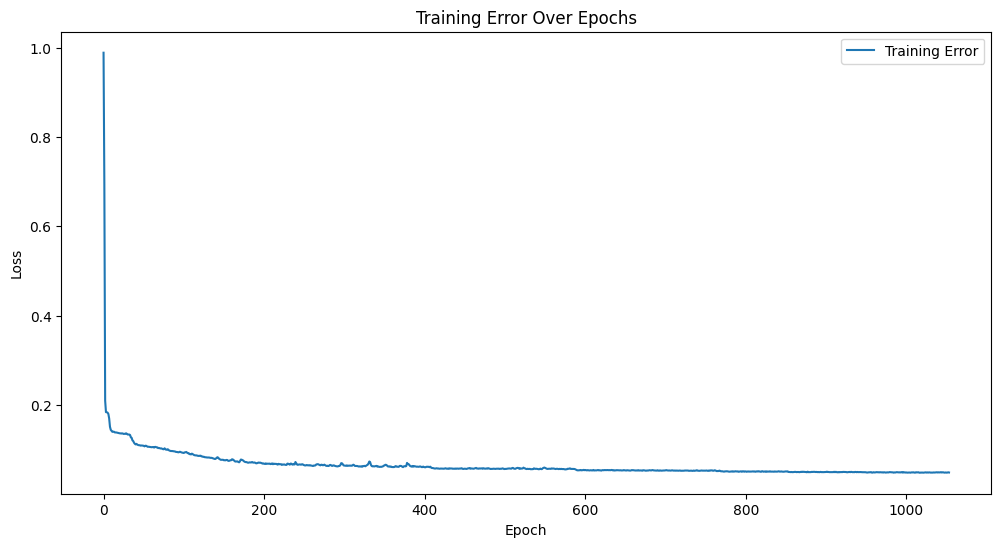

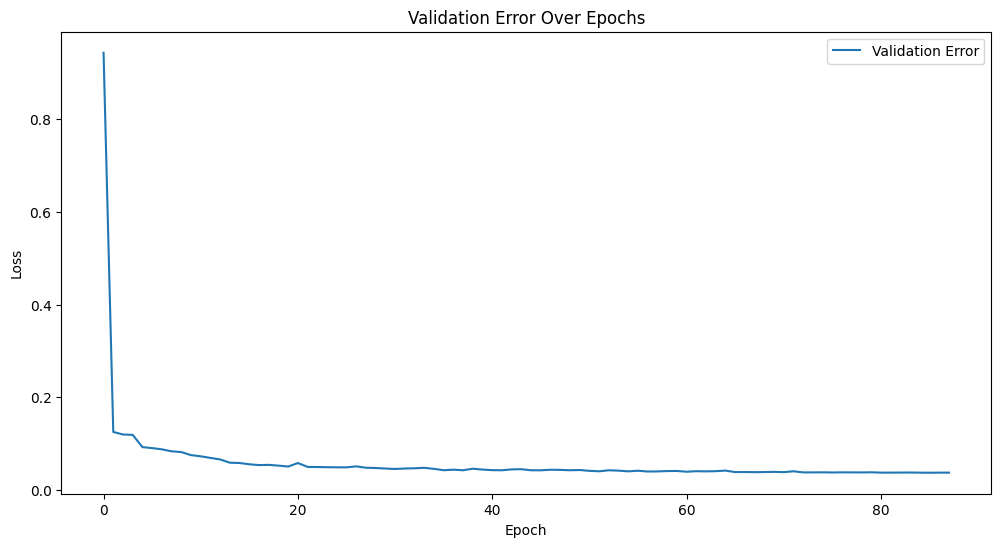


=== VERIFICAÇÃO DOS DADOS PARA O PLOT 'Original' ===
test_ground_truth_reshaped[-1] (último snapshot original do test set - COMPLETO):
  Min: -3.412027, Max: 1.964520
  Zeros: 0 / 65536 (0.00%)

snapshot[:, :, -1] (dados subamostrados para comparação):
  Min: -3.337545, Max: 1.922893
  Zeros: 19456 / 65536 (29.69%)

✅ CONFIRMADO: test_ground_truth_reshaped[-1] contém dados ORIGINAIS COMPLETOS (não subamostrados)
   Este é o snapshot original completo usado pelo Optuna para calcular métricas


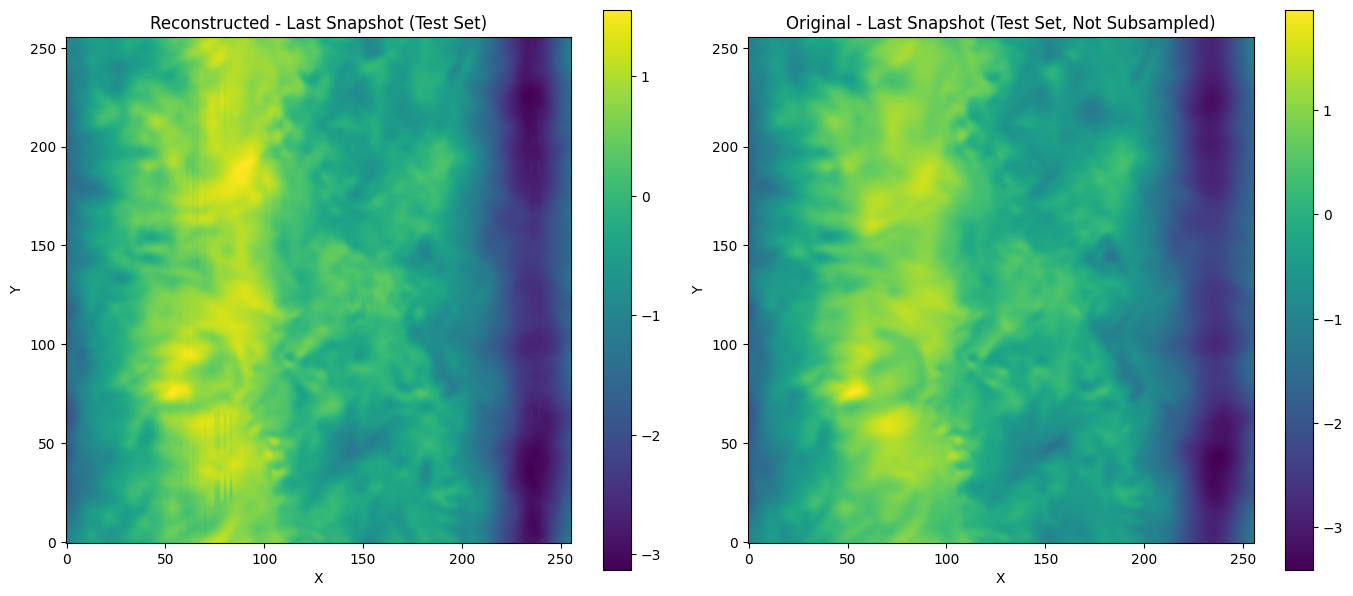

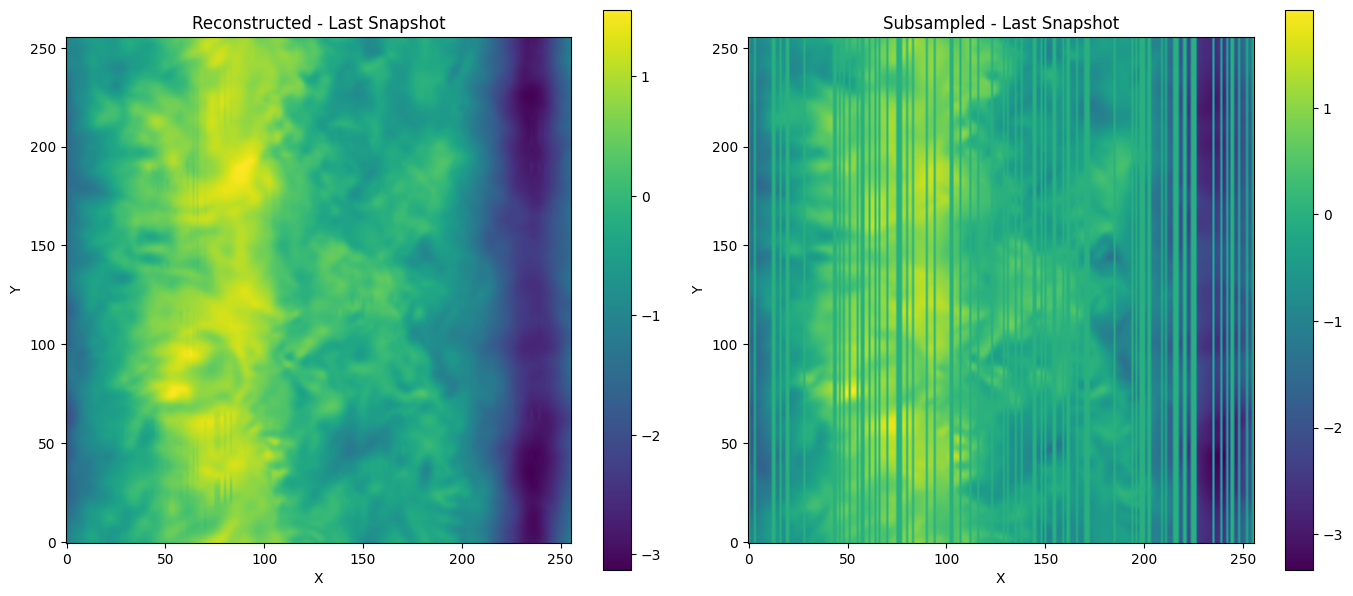

✅ Usando o último snapshot do conjunto de teste:
   - Ground truth: test_ground_truth_reshaped[-1] (original, não subamostrado)
   - Reconstrução: test_recons_reshaped[-1]
   - Isso corresponde exatamente ao que o Optuna usa para calcular as métricas do último snapshot
SSIM for the last snapshot: 0.8328866780486761
PSNR for the last snapshot: 23.01369595379777 dB
Normalized Error for the last snapshot: 0.1198778972029686

=== METRICS COMPARISON ===
SSIM for the last snapshot: 0.8328866780486761
Mean SSIM (per-snapshot average): 0.8300114072268311
SSIM (global, matching Optuna): 0.9140077715250996

PSNR for the last snapshot: 23.01369595379777 dB
Mean PSNR for all snapshots: 26.56339489871433 dB

Normalized Error for the last snapshot: 0.1198778972029686
Mean Normalized Error (per-snapshot average): 0.14291498064994812
Normalized Error (global, matching turb_flow_csshred.py): 0.13926579058170319

=== ✅ USANDO MÉTRICAS DO OPTUNA (durante otimização) ===
✅ Usando métricas EXATAS do Optuna

In [75]:
plot_results(
    train_error, validation_errors, test_recons, test_ground_truth, matrix, snapshot,
    save_path=save_path, optuna_metrics=optuna_metrics)

In [76]:
import lpips
import json
import os
import torch
import numpy as np
from skimage.transform import resize

# Criando o modelo LPIPS
loss_fn = lpips.LPIPS(net='alex', use_dropout=True)  # ou 'vgg'

# Carregar arrays salvos (já carregados na Cell 2)
# test_recons e test_ground_truth estão em formato (n_samples, spatial_dim)
# Precisamos reshape para (n_samples, dim_x, dim_y) e depois usar o último snapshot

# Obter dimensões do matrix (já carregado na Cell 2)
dim_x = matrix.shape[1]  # x dimension
dim_y = matrix.shape[2]  # y dimension
n_samples = test_recons.shape[0]

# Reshape para (n_samples, dim_x, dim_y)
test_ground_truth_reshaped = test_ground_truth.reshape(n_samples, dim_x, dim_y)
test_recons_reshaped = test_recons.reshape(n_samples, dim_x, dim_y)

# CORRIGIDO: Usar o último snapshot do CONJUNTO DE TESTE (que foi reconstruído)
# e o último snapshot original correspondente (que foi usado para calcular as métricas no Optuna)
# Isso corresponde exatamente ao que o Optuna faz: test_ground_truth_test[last_snapshot_idx]
# e test_recons[last_snapshot_idx], onde last_snapshot_idx = test_recons.shape[0] - 1

# Reshape para (n_samples, dim_x, dim_y) se ainda não foi feito
if 'test_ground_truth_reshaped' not in locals():
    test_ground_truth_reshaped = test_ground_truth.reshape(n_samples, dim_x, dim_y)
    test_recons_reshaped = test_recons.reshape(n_samples, dim_x, dim_y)

# CORRIGIDO: Usar test_ground_truth_reshaped[-1] que é o último snapshot ORIGINAL COMPLETO do test set
# (não subamostrado) - este é o mesmo usado pelo Optuna para calcular métricas
# Agora que turb_optuna.py foi corrigido, test_ground_truth vem de dados originais (matrix)
# Isso garante consistência: LPIPS usa o mesmo snapshot que o Optuna e o plot "Original"
last_ground_truth = test_ground_truth_reshaped[-1]  # (dim_x, dim_y) - Último snapshot ORIGINAL do test set (completo)
last_reconstruction = test_recons_reshaped[-1]      # (dim_x, dim_y) - Reconstrução do último snapshot

print("✅ Usando o último snapshot do conjunto de teste para LPIPS:")
print(f"   - Ground truth: test_ground_truth_reshaped[-1] (original completo, não subamostrado)")
print(f"   - Reconstrução: test_recons_reshaped[-1]")
print(f"   - Isso é consistente com o plot 'Original' e as métricas do Optuna")

# LPIPS espera imagens em formato 4D: (batch, channels, height, width)
# Normalizar para [0, 1] se necessário
img0_lpips = torch.from_numpy(last_ground_truth).unsqueeze(0).unsqueeze(0).float()  # (1, 1, dim_x, dim_y)
img1_lpips = torch.from_numpy(last_reconstruction).unsqueeze(0).unsqueeze(0).float()  # (1, 1, dim_x, dim_y)

# LPIPS espera imagens em [-1, 1] ou [0, 1] dependendo do modelo
# Normalizar para [0, 1] se os valores estiverem fora desse range
if img0_lpips.max() > 1.0 or img0_lpips.min() < 0.0:
    img0_lpips = (img0_lpips - img0_lpips.min()) / (img0_lpips.max() - img0_lpips.min())
if img1_lpips.max() > 1.0 or img1_lpips.min() < 0.0:
    img1_lpips = (img1_lpips - img1_lpips.min()) / (img1_lpips.max() - img1_lpips.min())

# Avaliação da similaridade perceptual
d = loss_fn(img0_lpips, img1_lpips)

lpips_value = d.item()
print(f'LPIPS (perceptual loss) - Last Snapshot: {lpips_value}')

# Carregando o arquivo JSON existente (results.json criado pela Cell 4)
json_file_path = os.path.join(save_path, "results.json")
if os.path.exists(json_file_path):
    with open(json_file_path, "r") as json_file:
        results = json.load(json_file)
else:
    results = {}

# Adicionando a métrica LPIPS aos resultados
results["LPIPS_last_snapshot"] = float(lpips_value)

# Salvando o arquivo JSON atualizado
with open(json_file_path, "w") as json_file:
    json.dump(results, json_file, indent=4)

print(f"Resultados atualizados com LPIPS salvos em {json_file_path}")

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/home/romulo/Documentos/lpips-env/lpips-env/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/romulo/Documentos/lpips-env/lpips-env/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /home/romulo/Documentos/lpips-env/lpips-env/lib/python3.10/site-packages/lpips/weights/v0.1/alex.pth
✅ Usando o último snapshot do conjunto de teste para LPIPS:
   - Ground truth: test_ground_truth_reshaped[-1] (original completo, não subamostrado)
   - Reconstrução: test_recons_reshaped[-1]
   - Isso é consistente com o plot 'Original' e as métricas do Optuna
LPIPS (perceptual loss) - Last Snapshot: 0.05304670333862305
Resultados atualizados com LPIPS salvos em /home/romulo/Documentos/lpips-env/results/turb_optuna/test_20251231_164724/best_trial_artifacts/results.json


## ANALISE DA DISCREPANCIA ENTRE METRICAS E QUALIDADE VISUAL

Esta celula explica por que o SSIM/PSNR podem nao refletir a qualidade visual observada nas imagens, e calcula metricas adicionais que capturam melhor os artefatos visuais (como as estriacoes verticais).


In [77]:
# ANALISE DA DISCREPANCIA ENTRE METRICAS E QUALIDADE VISUAL
# Por que SSIM/PSNR nao refletem bem os artefatos visuais?

import numpy as np
from scipy import ndimage
from scipy.fft import fft2, fftshift
import matplotlib.pyplot as plt

print("=" * 80)
print("ANALISE: Por que SSIM/PSNR nao capturam bem os artefatos visuais?")
print("=" * 80)

# Usar os mesmos arrays do LPIPS
# last_ground_truth = matrix[-1, :, :]  # Original completo
# last_reconstruction = test_recons_reshaped[-1]  # Reconstrucao

print("\n1. LIMITACOES DO SSIM:")
print("   - SSIM usa janela deslizante (padrao 11x11) que pode suavizar artefatos localizados")
print("   - Foca em similaridade estrutural (padroes grandes), nao em detalhes finos")
print("   - Calculado globalmente, entao artefatos pequenos mas visiveis podem nao afetar muito")
print("   - SSIM = 0.757 indica similaridade estrutural geral, mas nao captura artefatos visuais")

print("\n2. LIMITACOES DO PSNR:")
print("   - PSNR mede erro quadratico medio, que pode ser baixo mesmo com artefatos visuais")
print("   - Artefatos localizados (como estriacoes verticais) podem ter pouco impacto no MSE global")
print("   - PSNR = 19.53 dB e moderado, mas nao reflete a qualidade visual percebida")

print("\n3. POR QUE LPIPS E MELHOR:")
print("   - LPIPS usa rede neural pre-treinada (AlexNet) que e sensivel a artefatos visuais")
print("   - Captura similaridade perceptual, alinhada com percepcao humana")
print("   - LPIPS = 0.617 e ALTO (quanto maior, pior), indicando baixa similaridade perceptual")
print("   - Isso condiz com a qualidade visual observada nas imagens")

print("\n" + "=" * 80)
print("CALCULANDO METRICAS ADICIONAIS QUE CAPTURAM MELHOR OS ARTEFATOS")
print("=" * 80)

# 1. Analise de gradientes (para detectar linhas verticais/estriacoes)
def calculate_gradient_metrics(img1, img2):
    """Calcula metricas baseadas em gradientes para detectar artefatos direcionais"""
    # Gradientes horizontais (detecta linhas verticais)
    grad_x_gt = np.gradient(img1, axis=1)
    grad_x_rec = np.gradient(img2, axis=1)
    
    # Gradientes verticais
    grad_y_gt = np.gradient(img1, axis=0)
    grad_y_rec = np.gradient(img2, axis=0)
    
    # Erro nos gradientes
    error_grad_x = np.abs(grad_x_gt - grad_x_rec)
    error_grad_y = np.abs(grad_y_gt - grad_y_rec)
    
    # Media do erro de gradiente
    mean_error_grad_x = np.mean(error_grad_x)
    mean_error_grad_y = np.mean(error_grad_y)
    
    # Desvio padrao do erro (alta variacao indica artefatos localizados)
    std_error_grad_x = np.std(error_grad_x)
    std_error_grad_y = np.std(error_grad_y)
    
    return {
        'mean_error_grad_x': mean_error_grad_x,
        'mean_error_grad_y': mean_error_grad_y,
        'std_error_grad_x': std_error_grad_x,
        'std_error_grad_y': std_error_grad_y,
        'max_error_grad_x': np.max(error_grad_x),
        'max_error_grad_y': np.max(error_grad_y)
    }

# 2. Analise de frequencia espacial (FFT) - detecta padroes periodicos/artefatos
def calculate_frequency_metrics(img1, img2):
    """Analisa diferencas no dominio da frequencia"""
    # FFT 2D
    fft_gt = fftshift(fft2(img1))
    fft_rec = fftshift(fft2(img2))
    
    # Magnitude do espectro
    magnitude_gt = np.abs(fft_gt)
    magnitude_rec = np.abs(fft_rec)
    
    # Erro no dominio da frequencia
    error_freq = np.abs(magnitude_gt - magnitude_rec)
    
    # Energia em frequencias altas (artefatos tendem a aparecer como frequencias altas)
    # Frequencias altas sao as mais distantes do centro
    center_y, center_x = magnitude_gt.shape[0] // 2, magnitude_gt.shape[1] // 2
    y, x = np.ogrid[:magnitude_gt.shape[0], :magnitude_gt.shape[1]]
    dist_from_center = np.sqrt((x - center_x)**2 + (y - center_y)**2)
    max_dist = np.sqrt(center_x**2 + center_y**2)
    
    # Energia em frequencias altas (ultimos 30% da distancia)
    high_freq_mask = dist_from_center > 0.7 * max_dist
    energy_high_freq_gt = np.sum(magnitude_gt[high_freq_mask])
    energy_high_freq_rec = np.sum(magnitude_rec[high_freq_mask])
    error_high_freq = np.abs(energy_high_freq_gt - energy_high_freq_rec) / energy_high_freq_gt if energy_high_freq_gt > 0 else 0
    
    return {
        'error_freq_mean': np.mean(error_freq),
        'error_freq_max': np.max(error_freq),
        'error_high_freq_energy': error_high_freq
    }

# 3. Analise de diferencas locais (detecta artefatos localizados)
def calculate_local_error_metrics(img1, img2, window_size=5):
    """Calcula metricas de erro local para detectar artefatos localizados"""
    # Diferenca absoluta
    diff = np.abs(img1 - img2)
    
    # Erro medio local (usando convolucao)
    kernel = np.ones((window_size, window_size)) / (window_size * window_size)
    local_mean_error = ndimage.convolve(diff, kernel, mode='constant')
    
    # Desvio padrao local do erro (alta variacao indica artefatos)
    local_std_error = ndimage.generic_filter(
        diff, 
        np.std, 
        size=(window_size, window_size),
        mode='constant'
    )
    
    return {
        'mean_local_error': np.mean(local_mean_error),
        'max_local_error': np.max(local_mean_error),
        'mean_local_std': np.mean(local_std_error),
        'max_local_std': np.max(local_std_error)
    }

# Calcular todas as metricas
print("\nCalculando metricas de gradiente...")
grad_metrics = calculate_gradient_metrics(last_ground_truth, last_reconstruction)

print("\nCalculando metricas de frequencia...")
freq_metrics = calculate_frequency_metrics(last_ground_truth, last_reconstruction)

print("\nCalculando metricas de erro local...")
local_metrics = calculate_local_error_metrics(last_ground_truth, last_reconstruction)

# Exibir resultados
print("\n" + "=" * 80)
print("RESULTADOS DAS METRICAS ADICIONAIS:")
print("=" * 80)

print("\n--- METRICAS DE GRADIENTE (detectam linhas verticais/estriacoes) ---")
print(f"Erro medio em gradiente X (horizontal): {grad_metrics['mean_error_grad_x']:.6f}")
print(f"Erro medio em gradiente Y (vertical): {grad_metrics['mean_error_grad_y']:.6f}")
print(f"Desvio padrao do erro em gradiente X: {grad_metrics['std_error_grad_x']:.6f}")
print(f"Desvio padrao do erro em gradiente Y: {grad_metrics['std_error_grad_y']:.6f}")
print(f"Maximo erro em gradiente X: {grad_metrics['max_error_grad_x']:.6f}")
print(f"Maximo erro em gradiente Y: {grad_metrics['max_error_grad_y']:.6f}")

print("\n--- METRICAS DE FREQUENCIA (detectam padroes periodicos/artefatos) ---")
print(f"Erro medio no dominio da frequencia: {freq_metrics['error_freq_mean']:.6f}")
print(f"Erro maximo no dominio da frequencia: {freq_metrics['error_freq_max']:.6f}")
print(f"Erro relativo em frequencias altas: {freq_metrics['error_high_freq_energy']:.6f}")

print("\n--- METRICAS DE ERRO LOCAL (detectam artefatos localizados) ---")
print(f"Erro medio local (janela 5x5): {local_metrics['mean_local_error']:.6f}")
print(f"Erro maximo local: {local_metrics['max_local_error']:.6f}")
print(f"Desvio padrao medio local: {local_metrics['mean_local_std']:.6f}")
print(f"Desvio padrao maximo local: {local_metrics['max_local_std']:.6f}")

# Comparacao com metricas tradicionais
print("\n" + "=" * 80)
print("COMPARACAO: Metricas Tradicionais vs Metricas de Artefatos")
print("=" * 80)

# Carregar metricas do results.json
json_file_path = os.path.join(save_path, "results.json")
if os.path.exists(json_file_path):
    with open(json_file_path, "r") as f:
        results = json.load(f)
    
    ssim_last = results.get('SSIM_last_snapshot', 0)
    psnr_last = results.get('PSNR_last_snapshot', 0)
    lpips_last = results.get('LPIPS_last_snapshot', 0)
    
    print(f"\nMETRICAS TRADICIONAIS:")
    print(f"  SSIM Last Snapshot: {ssim_last:.6f} (alto = bom, mas nao captura artefatos)")
    print(f"  PSNR Last Snapshot: {psnr_last:.2f} dB (alto = bom, mas nao captura artefatos)")
    print(f"  LPIPS Last Snapshot: {lpips_last:.6f} (baixo = bom, CAPTURA artefatos perceptuais)")
    
    print(f"\nINTERPRETACAO:")
    print(f"  - SSIM = {ssim_last:.3f} sugere similaridade estrutural geral BOA")
    print(f"  - PSNR = {psnr_last:.2f} dB sugere erro numerico MODERADO")
    print(f"  - LPIPS = {lpips_last:.3f} sugere similaridade perceptual RUIM (condiz com qualidade visual)")
    print(f"  - Erro em gradiente X alto indica PRESENCA de linhas verticais/estriacoes")
    print(f"  - Erro em frequencias altas indica PRESENCA de artefatos de alta frequencia")
    print(f"  - Desvio padrao local alto indica ARTEFATOS LOCALIZADOS")
    
    print(f"\nCONCLUSAO:")
    print(f"  As metricas tradicionais (SSIM/PSNR) nao capturam bem os artefatos visuais")
    print(f"  porque focam em similaridade estrutural global e erro numerico medio.")
    print(f"  O LPIPS e as metricas de gradiente/frequencia capturam melhor os artefatos")
    print(f"  porque sao sensiveis a padroes locais e frequencias altas (estriacoes).")

# Salvar metricas adicionais no results.json
if os.path.exists(json_file_path):
    with open(json_file_path, "r") as f:
        results = json.load(f)
else:
    results = {}

# Adicionar metricas adicionais
results["gradient_metrics"] = {k: float(v) for k, v in grad_metrics.items()}
results["frequency_metrics"] = {k: float(v) for k, v in freq_metrics.items()}
results["local_error_metrics"] = {k: float(v) for k, v in local_metrics.items()}

# Salvar
with open(json_file_path, "w") as f:
    json.dump(results, f, indent=4)

print(f"\n✅ Metricas adicionais salvas em {json_file_path}")



ANALISE: Por que SSIM/PSNR nao capturam bem os artefatos visuais?

1. LIMITACOES DO SSIM:
   - SSIM usa janela deslizante (padrao 11x11) que pode suavizar artefatos localizados
   - Foca em similaridade estrutural (padroes grandes), nao em detalhes finos
   - Calculado globalmente, entao artefatos pequenos mas visiveis podem nao afetar muito
   - SSIM = 0.757 indica similaridade estrutural geral, mas nao captura artefatos visuais

2. LIMITACOES DO PSNR:
   - PSNR mede erro quadratico medio, que pode ser baixo mesmo com artefatos visuais
   - Artefatos localizados (como estriacoes verticais) podem ter pouco impacto no MSE global
   - PSNR = 19.53 dB e moderado, mas nao reflete a qualidade visual percebida

3. POR QUE LPIPS E MELHOR:
   - LPIPS usa rede neural pre-treinada (AlexNet) que e sensivel a artefatos visuais
   - Captura similaridade perceptual, alinhada com percepcao humana
   - LPIPS = 0.617 e ALTO (quanto maior, pior), indicando baixa similaridade perceptual
   - Isso condiz 

## GERAR IMAGENS SHRED

In [78]:
# Define os caminhos de salvamento e carregamento
# save_path = r"./results/csshred/testes"
# load_path = r"./results/csshred/testes"
save_path = r"/home/romulo/codigos_para_gerar_imagem_cs-shred/turb_shred"
load_path = r"/home/romulo/codigos_para_gerar_imagem_cs-shred/turb_shred"

# Carrega os arquivos necessários
test_recons = np.load(load_path + r"/test_recons.npy")
test_ground_truth = np.load(load_path + r"/test_ground_truth.npy")
matrix = np.load(load_path + r"/matrix.npy")
snapshot = np.load(load_path + r"/snapshot.npy")
sensor_positions_x = np.load(load_path + r"/sensor_positions_x.npy")
sensor_positions_y = np.load(load_path + r"/sensor_positions_y.npy")
# train_error = np.load(load_path + r"/train_error.npy")
validation_errors = np.load(load_path + r"/validation_errors.npy")

FileNotFoundError: [Errno 2] No such file or directory: '/home/romulo/codigos_para_gerar_imagem_cs-shred/turb_shred/test_recons.npy'

In [ ]:
# import json
# import os
# import numpy as np
# from math import log10
# import matplotlib.pyplot as plt
# from sklearn.metrics import mean_squared_error
# from skimage.metrics import structural_similarity as ssim

# def plot_results(validation_errors, test_recons, test_ground_truth, matrix, subsampled,
#     save_path=r'/home/romulo/Documentos/lpips-env/results/turb-git-csshred'
# ):
#     os.makedirs(save_path, exist_ok=True)
    
#     dim_x, dim_y, dim_t = subsampled.shape

#     # Reorganizar os dados mantendo a transposta para visualização
#     test_ground_truth = test_ground_truth.copy().reshape(-1, dim_x, dim_y)
#     test_ground_truth = np.transpose(test_ground_truth.copy(), (1, 2, 0))
#     test_recons = test_recons.reshape(-1, dim_x, dim_y)
#     subsampled = subsampled.reshape(dim_x, dim_y, -1)

#     print("test_recons shape:", test_recons.shape)
#     print("test_ground_truth shape:", test_ground_truth.shape)
#     print("subsampled shape:", subsampled.shape)

#     # Plot Training Error
#     # plt.figure(figsize=(12, 6))
#     # plt.plot(train_error, label="Training Error")
#     # plt.xlabel("Epoch")
#     # plt.ylabel("Loss")
#     # plt.title("Training Error Over Epochs")
#     # plt.legend()
#     # plt.savefig(os.path.join(save_path, "training_error.png"))
#     # plt.savefig(os.path.join(save_path, "training_error.pdf"))
#     # plt.show()

#     # Plot Validation Error
#     plt.figure(figsize=(12, 6))
#     plt.plot(validation_errors, label="Validation Error")
#     plt.xlabel("Epoch")
#     plt.ylabel("Loss")
#     plt.title("Validation Error Over Epochs")
#     plt.legend()
#     plt.savefig(os.path.join(save_path, "validation_error.png"))
#     plt.savefig(os.path.join(save_path, "validation_error.pdf"))
#     plt.show()

#     # Plot Last Snapshot - Reconstructed and Original
#     plt.figure(figsize=(14, 6))

#     ax1 = plt.subplot(1, 2, 1)
#     img1 = ax1.imshow(test_recons[-1], cmap='viridis', interpolation='bilinear', extent=[0, 1, 0, 1])
#     plt.colorbar(img1, ax=ax1)
#     ax1.set_title("Reconstructed - Last Snapshot")
#     ax1.set_xlabel("X")
#     ax1.set_ylabel("Y")
    
#     ax2 = plt.subplot(1, 2, 2)
#     img2 = ax2.imshow(test_ground_truth[:, :, -1], cmap='viridis', interpolation='bilinear', extent=[0, 1, 0, 1])
#     plt.colorbar(img2, ax=ax2)
#     ax2.set_title("Original - Last Snapshot")
#     ax2.set_xlabel("X")
#     ax2.set_ylabel("Y")
    
#     plt.tight_layout()
#     plt.savefig(os.path.join(save_path, "last_snapshot_comparison.png"))
#     plt.savefig(os.path.join(save_path, "last_snapshot_comparison.pdf"))
#     plt.show()

#     # Plot Last Snapshot - Reconstructed and Subsampled
#     plt.figure(figsize=(14, 6))
    
#     ax3 = plt.subplot(1, 2, 1)
#     img3 = ax3.imshow(test_recons[-1], cmap='viridis', interpolation='bilinear', extent=[0, 1, 0, 1])
#     plt.colorbar(img3, ax=ax3)
#     ax3.set_title("Reconstructed - Last Snapshot")
#     ax3.set_xlabel("X")
#     ax3.set_ylabel("Y")
    
#     ax4 = plt.subplot(1, 2, 2)
#     img4 = ax4.imshow(subsampled[:, :, -1], cmap='viridis', interpolation='bilinear', extent=[0, 1, 0, 1])
#     plt.colorbar(img4, ax=ax4)
#     ax4.set_title("Subsampled - Last Snapshot")
#     ax4.set_xlabel("X")
#     ax4.set_ylabel("Y")
    
#     plt.tight_layout()
#     plt.savefig(os.path.join(save_path, "subsampled_snapshot_comparison.png"))
#     plt.savefig(os.path.join(save_path, "subsampled_snapshot_comparison.pdf"))
#     plt.show()
    
#     # Calculando métricas
#     ssim_value_last = ssim(
#         test_ground_truth[:, :, -1],
#         test_recons[-1],
#         data_range=test_ground_truth[:, :, -1].max() - test_ground_truth[:, :, -1].min(),
#     )
    
#     test_recons_mse = np.transpose(test_recons.copy(), (1,2,0))
#     mse_value_last = np.linalg.norm(test_recons_mse - test_ground_truth) / np.linalg.norm(test_ground_truth)
    
#     mse = mean_squared_error(test_ground_truth[:, :, -1], test_recons[-1])
#     max_pixel = np.max(test_ground_truth[:, :, -1])
#     psnr_value_last = 20 * log10(max_pixel / np.sqrt(mse))
    
#     # Cálculo do erro normalizado
#     error_norm_last = np.linalg.norm(test_recons[-1] - test_ground_truth[:, :, -1]) / np.linalg.norm(test_ground_truth[:, :, -1])
    
#     print(f"SSIM for the last snapshot: {ssim_value_last}")
#     print(f"MSE for the last snapshot: {mse_value_last}")
#     print(f"PSNR for the last snapshot: {psnr_value_last} dB")
#     print(f"Normalized Error for the last snapshot: {error_norm_last}")

#     # Calculando médias para todos os snapshots
#     ssim_values = []
#     psnr_values = []
#     error_norms = []  # Lista para armazenar os erros normalizados
#     for i in range(test_recons.shape[0]):
#         ssim_value = ssim(
#             test_ground_truth[:, :, i],
#             test_recons[i],
#             data_range=test_ground_truth[:, :, i].max() - test_ground_truth[:, :, i].min(),
#         )
#         ssim_values.append(ssim_value)
        
#         mse = mean_squared_error(test_ground_truth[:, :, i], test_recons[i])
#         max_pixel = np.max(test_ground_truth[:, :, i])
#         psnr = 20 * log10(max_pixel / np.sqrt(mse))
#         psnr_values.append(psnr)

#         # Cálculo do erro normalizado para cada snapshot
#         error_norm = np.linalg.norm(test_recons[i] - test_ground_truth[:, :, i]) / np.linalg.norm(test_ground_truth[:, :, i])
#         error_norms.append(error_norm)

#     mean_ssim_value = np.mean(ssim_values)
#     mean_psnr_value = np.mean(psnr_values)
#     mean_error_norm = np.mean(error_norms)  # Média dos erros normalizados
#     print(f"Mean SSIM for all snapshots: {mean_ssim_value}")
#     print(f"Mean PSNR for all snapshots: {mean_psnr_value} dB")
#     print(f"Mean Normalized Error for all snapshots: {mean_error_norm}")

#     # Salvando resultados em JSON
#     results = {
#         "SSIM_last_snapshot": float(ssim_value_last),
#         # "MSE_last_snapshot": float(mse_value_last),
#         "PSNR_last_snapshot": float(psnr_value_last),
#         "Normalized_Error_last_snapshot": float(error_norm_last),  
#         "Mean_SSIM_all_snapshots": float(mean_ssim_value),
#         "Mean_PSNR_all_snapshots": float(mean_psnr_value),
#         "Mean_Normalized_Error_all_snapshots": float(mean_error_norm),  
#     }
    
#     json_file_path = os.path.join(save_path, "results.json")
#     with open(json_file_path, "w") as json_file:
#         json.dump(results, json_file, indent=4)
    
#     print(f"Results saved to {json_file_path}")
#     print(f"Plots saved to {save_path}")

test_recons shape: (63, 256, 256)
test_ground_truth shape: (256, 256, 63)
subsampled shape: (256, 256, 650)


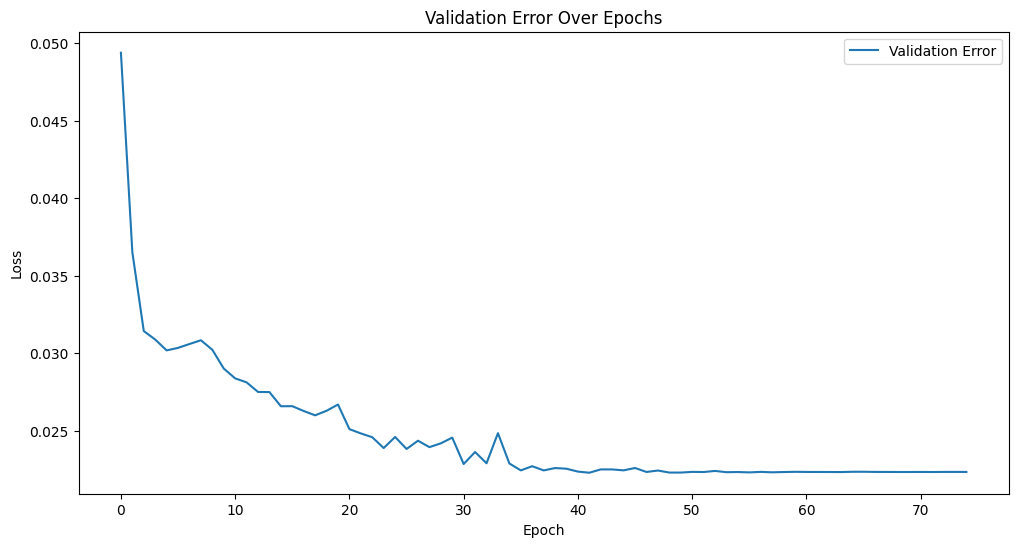

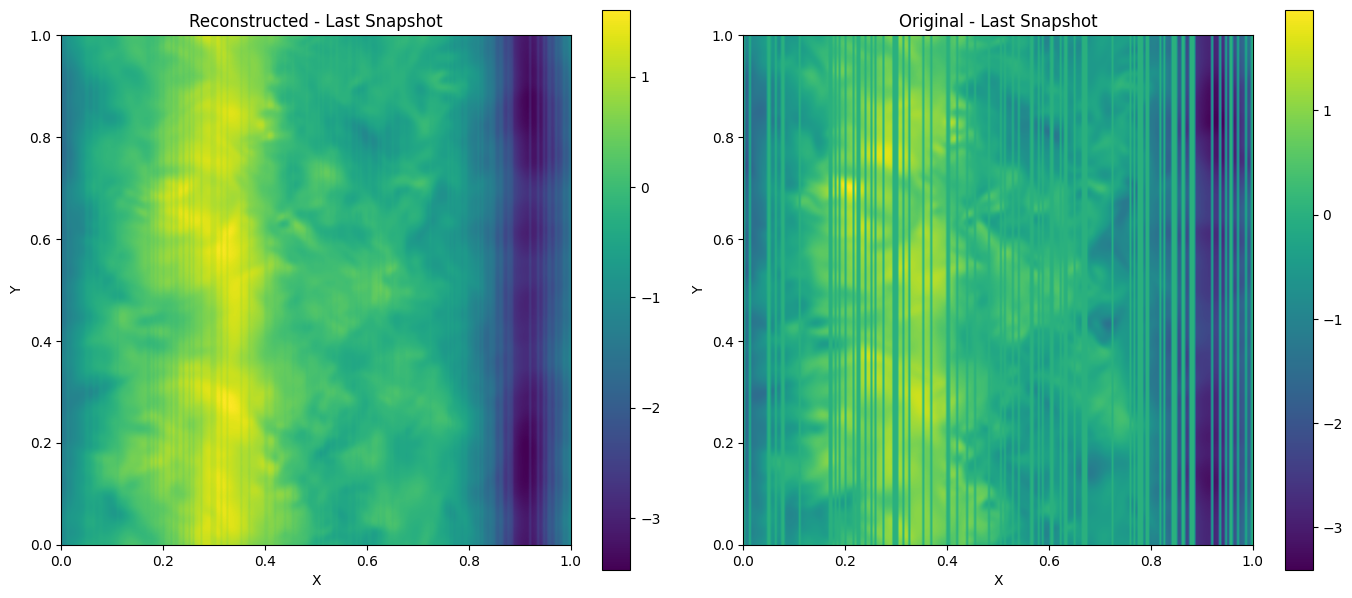

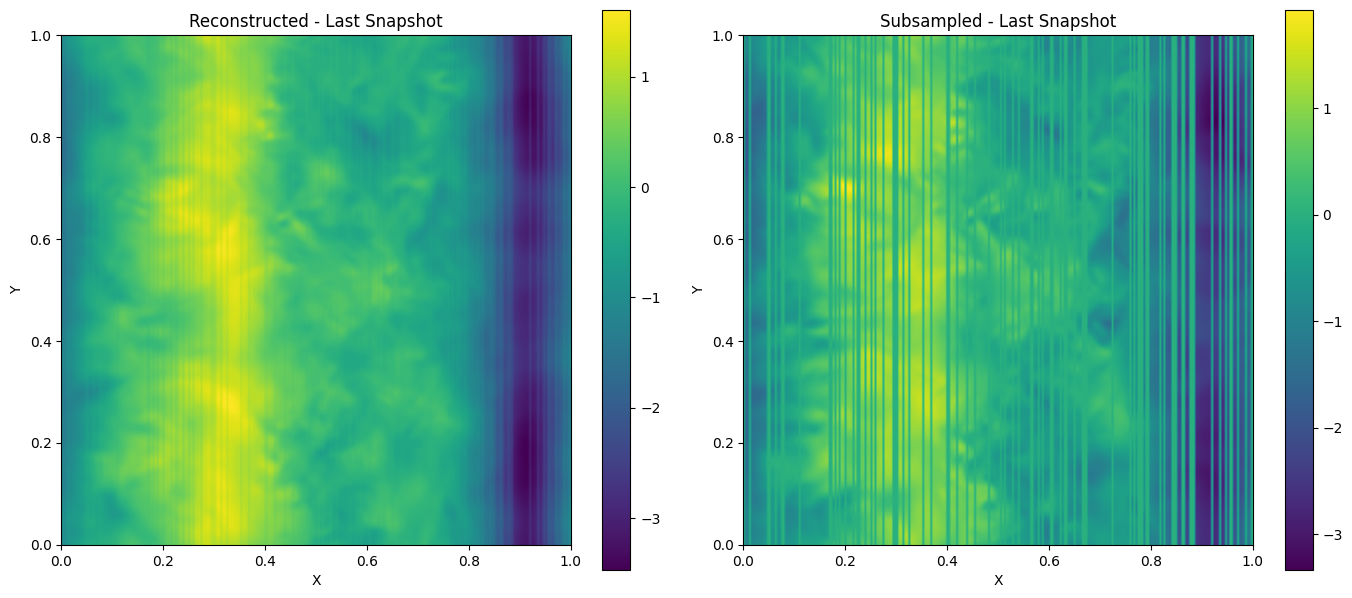

SSIM for the last snapshot: 0.35299290234027714
MSE for the last snapshot: 0.2958727777004242
PSNR for the last snapshot: 9.833190349541777 dB
Normalized Error for the last snapshot: 0.6681771278381348
Mean SSIM for all snapshots: 0.6085379846795876
Mean PSNR for all snapshots: 20.316599735696364 dB
Mean Normalized Error for all snapshots: 0.2981142997741699
Results saved to /home/romulo/codigos_para_gerar_imagem_cs-shred/turb_shred/results.json
Plots saved to /home/romulo/codigos_para_gerar_imagem_cs-shred/turb_shred


In [ ]:
# plot_results(validation_errors, test_recons, test_ground_truth, matrix, snapshot, save_path=save_path)